# Project - Introduction

## Problem formulation

The parametrised problem considered is the following: given $\Omega=(0,1)^2$, $\boldsymbol\mu=(\mu_0,\mu_1)\in\mathcal P=[0.1,1]^2$, find $u(\mathbf x;\boldsymbol\mu)$ such that
$$
    \begin{cases}
        -\Delta u(\boldsymbol\mu)+
        \frac{\mu_0}{\mu_1}\left(e^{\mu_1u(\boldsymbol\mu)}-1\right)=
        g(\mathbf x;\boldsymbol\mu)&\text{in }\Omega,\\
        u=0&\text{in }\partial\Omega,
    \end{cases}
$$
where
$$
    g(\mathbf x;\boldsymbol\mu)\equiv g_1=100\sin(2\pi x_0)\cos(2\pi x_1)\quad\forall\mathbf x=(x_0,x_1)\in\Omega
$$
or 
$$
    g(\mathbf x;\boldsymbol\mu)\equiv g_2=100\sin(2\pi\mu_0x_0)\cos(2\pi\mu_0x_1)\quad\forall\mathbf x=(x_0,x_1)\in\Omega,
$$
and the exact solution $u(\mathbf x;\boldsymbol\mu)$ is not known beforehand. The weak form requires to find $u \in V\equiv H^1_0(\Omega)$ so that
$$
    \int_\Omega\nabla u\nabla v
    +\int_\Omega\frac{\mu_0}{\mu_1}e^{\mu_1u(\boldsymbol\mu)}v
    =\int_\Omega\left(g+\frac{\mu_0}{\mu_1}\right)v
    \quad\forall v\in V.
$$
and by using the Galerkin method it's not possible to find the respective matrix form due to the non linear operator associated with the exponential.

In [ ]:
import os
print("Current working directory:",os.getcwd())

import sys
sys.path.append('../../../../CppToPython')

import numpy as np
import GeDiM4Py as gedim

lib = gedim.ImportLibrary("../../../../CppToPython/release/GeDiM4Py.so")
config = { 'GeometricTolerance': 1.0e-8 }
gedim.Initialize(config,lib)

import matplotlib as mlt
import matplotlib.pyplot as plt
from matplotlib import cm
from PIL import Image

import numpy as np

# from IPython.display import clear_output
# from IPython.display import display, DisplayHandle

import importlib
import libMOR
importlib.reload(libMOR)

Current working directory: /content/workfolder/LOReduX/Project/Code


<module 'libMOR' from '/content/workfolder/LOReduX/Project/Code/libMOR.py'>

## FOM solution by Netwon method

By recasting the weak form of the nonlinear problem, one has to find $u \in V\equiv H^1_0(\Omega)$ so that
$$
    f(u;v)\equiv
    \underbrace{\int_\Omega\nabla u\nabla v}_{f_1(u,v)}
    +\underbrace{\int_\Omega\frac{\mu_0}{\mu_1}e^{\mu_1u(\boldsymbol\mu)}v}_{f_2(u,v)}
    -\underbrace{\int_\Omega\left(g+\frac{\mu_0}{\mu_1}\right)v}_{f_3(v)}=
    f_1(u,v)+f_2(u,v)+f_3(v)=0
    \quad\forall v\in V.
$$
Using Newton's method, one has to iteratively update the solution with $u_{k+1}=\delta u+u_k$ where $\delta u$ is the solution of the linear system
$$
    J_f[\delta u]|_{u_k}\delta u=- f(u_k,v)
    \quad\forall v \in V,
$$
in which $J_f[\delta u]|_{u_k}$ is the evaluation of the Jacobian of $f$ in the point $u_k$ along the unknown direction of $\delta u$ defined as
$$
    J_f[\delta u]|_{u_k}=\lim_{h\rightarrow0}{\frac{f(u_k+h\delta u)-f(u_k)}{h}},
$$
assuming $f$ is Gateaux differentiable. Then it's clear that $J_{f_1}[\delta u]|_{u_k}=\int_\Omega\nabla\delta u\nabla v$, for the linearity of $f_1$, while $J_{f_3}[\delta u]|_{u_k}=0$, as it does not depend on $u$; thus, the only Jacobian necessary to calculate is $J_{f_2}[\delta u]|_{u_k}$:
$$
    \begin{align*}
        J_{f_2}[\delta u]|_{u_k}&=
        \lim_{h\rightarrow0}{\frac1h\left[\int_\Omega\frac{\mu_0}{\mu_1}e^{\mu_1(u_k+h\delta u)}v-\int_\Omega \frac{\mu_0}{\mu_1}e^{\mu_1u_k}v\right]}
        \\&=\lim_{h\rightarrow0}{\frac1h\left[\int_\Omega\frac{\mu_0}{\mu_1}\left(e^{\mu_1u_k}e^{\mu_1h\delta u}-e^{\mu_1u_k}\right)v\right]}
        \\&=\lim_{h\rightarrow0}{\frac1h\left[\int_\Omega\frac{\mu_0}{\mu_1}\left(e^{\mu_1h\delta u}-1\right)e^{\mu_1u_k}v\right]}
        \\&=\lim_{h\rightarrow0}{\frac1h\left[\int_\Omega\frac{\mu_0}{\mu_1}\left(1+\mu_1h\delta u-1\right)e^{\mu_1u_k}v\right]}
        \\&=\int_\Omega\mu_0\delta ue^{\mu_1u_k}v,
    \end{align*}
$$
where $e^{\mu_1h\delta u}≈1+\mu_1h\delta u$ is valid only with $h\ll1$ as is the case when $h\rightarrow0$. To conclude the weak form to solve in each iteration $k$ is
$$
    \int_\Omega\nabla\delta u\cdot\nabla v
    +\mu_0\int_\Omega\delta ue^{\mu_1u_k}v=
    -\int_\Omega\nabla u_k\cdot\nabla v
    -\frac{\mu_0}{\mu_1}\int_\Omega e^{\mu_1u_k}v
    +\int_\Omega gv
    +\frac{\mu_0}{\mu_1}\int_\Omega v,
$$
which using the Galerkin method, since every operator is now linear with respect to $\delta u$, lead to the linear system
$$
    \mathbf A\delta\mathbf u\equiv
    (\mathbf A^{\text{Stiff}}+\mu_0\mathbf A^{\text{NL}}(\mu_1))\delta\mathbf u=
    -\mathbf g^{\text{Stiff}}-\frac{\mu_0}{\mu_1}\mathbf g^{\text{NL}}(\mu_1)
    +\mathbf g^{\text{FTg}}+\frac{\mu_0}{\mu_1}\mathbf g^{\text{FTf}}
    \equiv\mathbf f,
$$
where three remarks are clear:
1. $\mathbf A^{\text{Stiff}}$, $\mathbf g^{\text{Stiff}}$ and $\frac{\mu_0}{\mu_1}\mathbf g^{\text{FTf}}$ are always affine with respect to $\boldsymbol\mu$,
2. $\mathbf A^{\text{NL}}(\mu_1)$ and $\mathbf g^{\text{NL}}(\mu_1)$ are always **not** affine and
3. $\mathbf g^{\text{FTg}}$ is affine with $g_1$ but **not** with $g_2$.


## Testing $\mathbb P_2$ error convergence

From the theory it's know that with $\mathbb P_2$ elements, FEM gives the following error inequalities:
$$
    \Vert u-u_h\Vert_{H^1(\Omega)}=\Vert u-u_h\Vert_{1,\Omega}≤Ch^2\vert u\vert_{3,\Omega}, u\in H^3(\Omega),\\
    \Vert u-u_h\Vert_{L^2(\Omega)}=\Vert u-u_h\Vert_{0,\Omega}≤Ch^3\vert u\vert_{3,\Omega}, u\in H^3(\Omega),\\
$$
where these formulas come respectively from (8.7) on p. 94 and (8.16) on p. 96 of the document «Numerical Methods for PDE» by Canuto and Berrone.

In [2]:
hMax   = 0.1 # Maximum area
nSim   = 5    # Number of simulations
aMaxR = np.array([hMax*(2**-x) for x in range(0,nSim)])

m0 = 1 # μ₀
m1 = 1 # μ₁
L  = 4

errL2 = np.zeros(nSim)
errH1 = np.zeros(nSim)

In [3]:
def u(matPoints): return (1/16)*matPoints[0,:]*(L - matPoints[0,:])*matPoints[1,:]*(L - matPoints[1,:])

def ExactSolution(numPoints,points):
	matPoints = gedim.make_nd_matrix(points,(3,numPoints),np.double)
	values = u(matPoints)
	return values.ctypes.data

def ExactDerivativeSolution(direction,numPoints,points):
	matPoints = gedim.make_nd_matrix(points,(3,numPoints),np.double)

	if direction == 0:   # Derivative along the x direction
		values = (1/16)*(L - 2*matPoints[0,:])*matPoints[1,:]*(L - matPoints[1,:])
	elif direction == 1: # Derivative along the y direction
		values = (1/16)*(L - 2*matPoints[1,:])*matPoints[0,:]*(L - matPoints[0,:])
	else:                # All other derivative
		values = np.zeros(numPoints)

	return values.ctypes.data
def g(matPoints): return (1/8)*(matPoints[0,:]*(L - matPoints[0,:]) + matPoints[1,:]*(L - matPoints[1,:])) \
                         + (m0/m1)*(np.exp(m1*u(matPoints)) - 1)

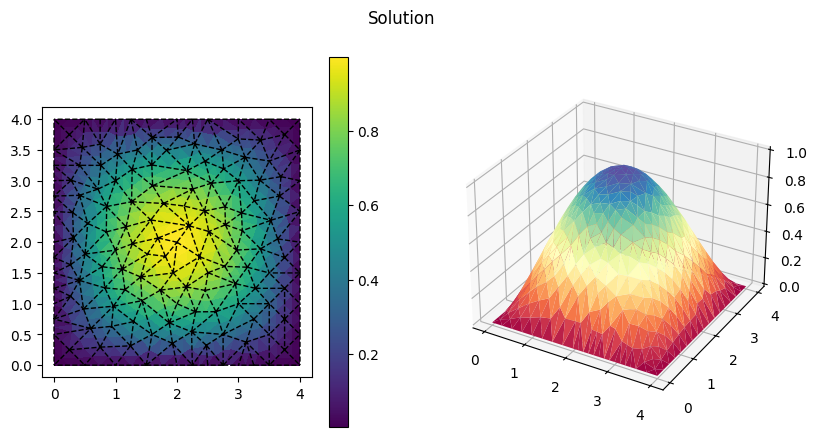

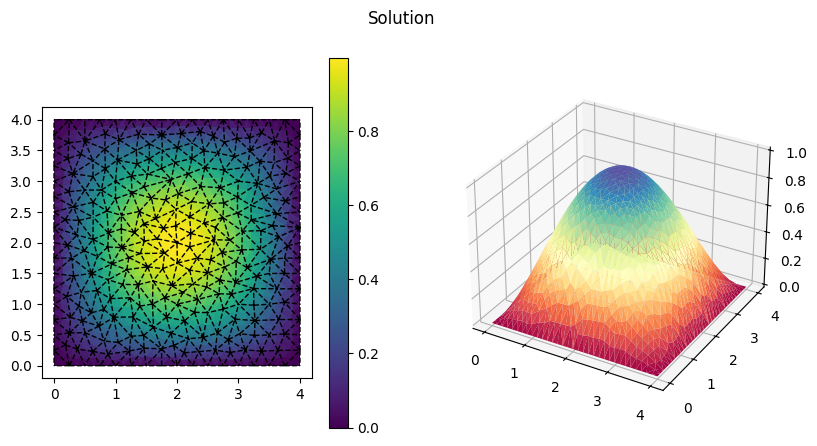

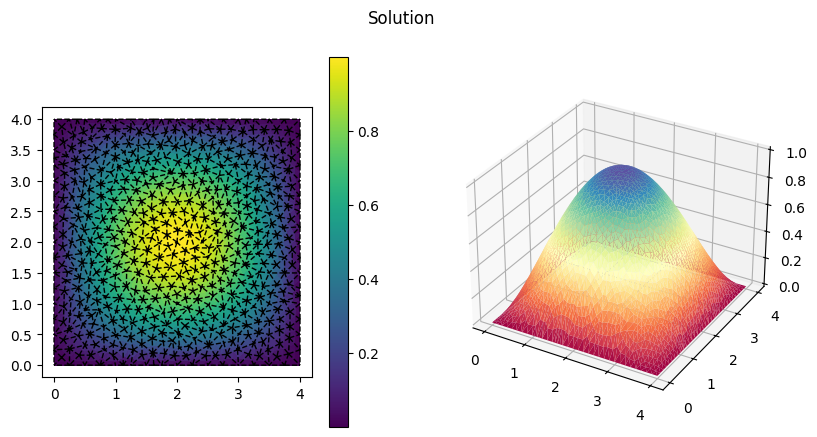

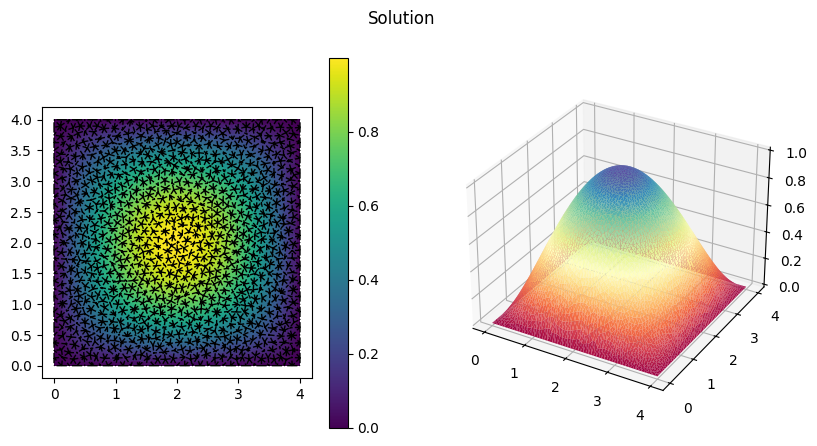

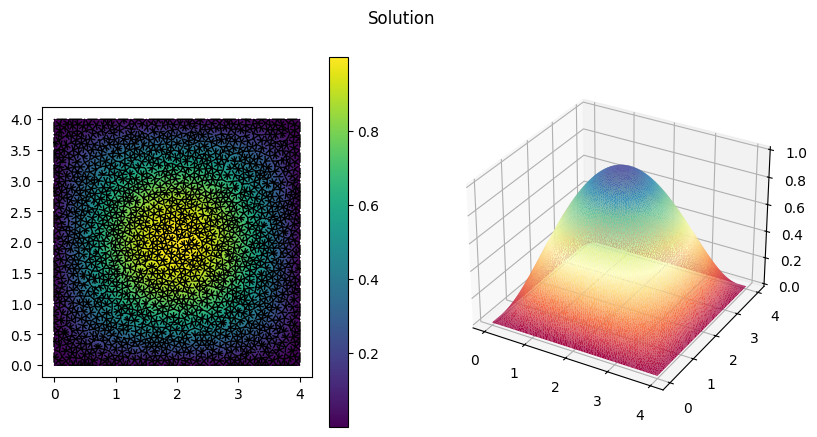

In [4]:
for s in range(0,nSim):

    aMax = aMaxR[s]
	
    [mesh, dofs, strongs, u_h, u_strong] = libMOR.FOMSol(L,aMax,2,m0,m1,g)
    gedim.PlotSolution(mesh,dofs,strongs,u_h,u_strong)
    
    errL2[s] = gedim.ComputeErrorL2(ExactSolution,u_h,u_strong,lib)
    errH1[s] = gedim.ComputeErrorH1(ExactDerivativeSolution,u_h,u_strong,lib)

    # clear_output(wait=True)

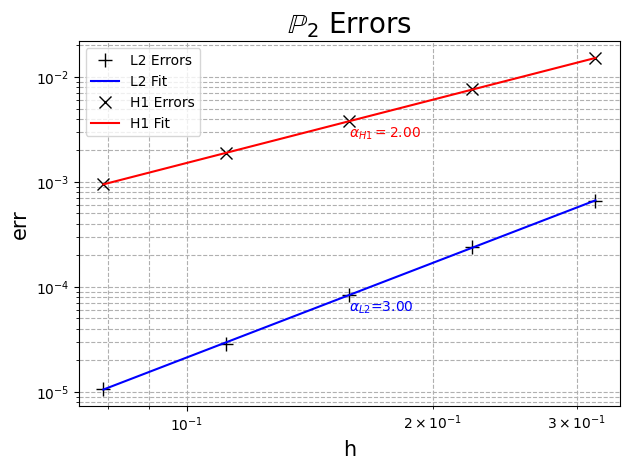

In [5]:
plt.rcParams['text.usetex'] = False

hMaxR = np.sqrt(aMaxR)

# Fitting the L2 errors with a line
pL2      = np.polyfit(np.log(hMaxR),np.log(errL2),1)
alfaL2   = pL2[0] # Slope of the line
errL2Fit = np.polyval(pL2,np.log(hMaxR)) # Evaluation of the line


# Fitting the H1 errors with a line
pH1      = np.polyfit(np.log(hMaxR),np.log(errH1),1)
alfaH1   = pH1[0] # Slope of the line
errH1Fit = np.polyval(pH1,np.log(hMaxR)) # Evaluation of the line


fig  = plt.figure()
midP = int(np.round(nSim/2))

plt.loglog(hMaxR,errL2,label='L2 Errors',marker='+', \
           markersize='10',linestyle='None',color='black')
plt.loglog(hMaxR,np.exp(errL2Fit),label='L2 Fit',color='blue')
plt.text(hMaxR[midP],0.9*np.exp(errL2Fit[midP]), \
         r"$\alpha_{L2}$="+'{:.2f}'.format(alfaL2), \
         fontsize=10,color='blue',va='top',ha='left')

plt.loglog(hMaxR,errH1,label='H1 Errors',marker='x', \
           markersize='8',linestyle='None',color='black')
plt.loglog(hMaxR,np.exp(errH1Fit),label='H1 Fit',color='red')
plt.text(hMaxR[midP],0.9*np.exp(errH1Fit[midP]), \
         r"$\alpha_{H1}=$"+'{:.2f}'.format(alfaH1),\
         fontsize=10,color='red',va='top',ha='left')

plt.title(r"$\mathbb{P}_2$ Errors",fontsize=20)

plt.xlabel("h",fontsize=15)
plt.ylabel("err",fontsize=15)
plt.legend(loc='best',fontsize=10)
plt.grid(True,which="both",ls="--")

fig.tight_layout()
plt.show()

## Assignment comparison with $g_1$

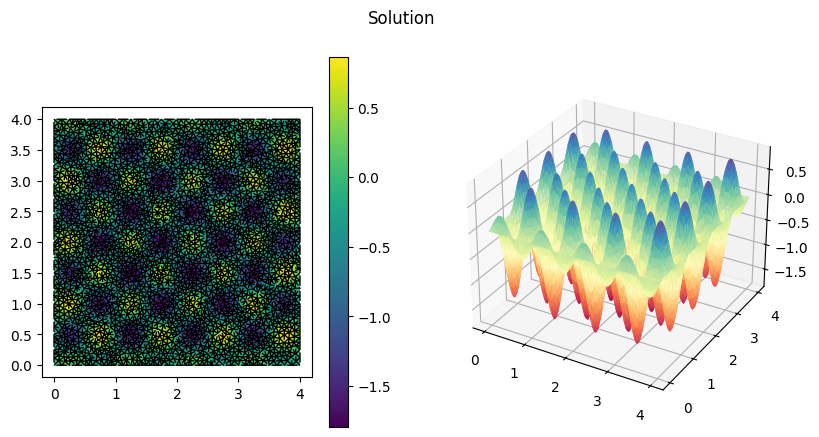

In [16]:
# Geometry definition
aMax  = 0.005
L     = 4

# Parameter definition
m0    = 3.34 # μ₀
m1    = 4.45 # μ₁

# FOM solution and plot
[mesh, dofs, strongs, u, u_strong] = libMOR.FOMSol1(L,aMax,2,m0,m1)
gedim.PlotSolution(mesh,dofs,strongs,u,u_strong)

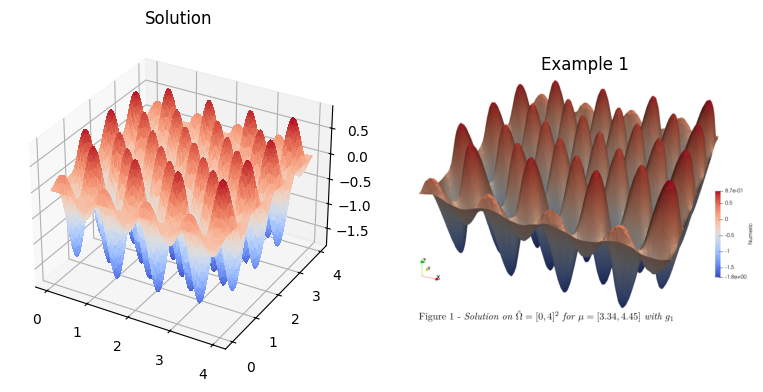

In [ ]:
# Comparison
x = np.concatenate((dofs[0,:],strongs[0,:]),axis=0)
y = np.concatenate((dofs[1,:],strongs[1,:]),axis=0)
z = np.concatenate((u,u_strong), axis=0)
triang = mlt.tri.Triangulation(x,y)

fig = plt.figure(figsize=plt.figaspect(0.5))

ax1  = fig.add_subplot(1,2,1,projection='3d')
surf = ax1.plot_trisurf(x,y,z,triangles=triang.triangles, \
                        cmap=cm.coolwarm,linewidth=0,antialiased=False)
ax1.set_title("Solution 1")

ax2 = fig.add_subplot(1,2,2)
imp = "../Figures/Example_1.png"
img = Image.open(imp)
ax2.imshow(img)
ax2.axis('off')
ax2.set_title("Example 1")

plt.show()
# plt.close(fig)

# Code taken and remixed from «PlotSolution» definition in «GeDiM4Py.py»

## Assignment comparison with $g_2$

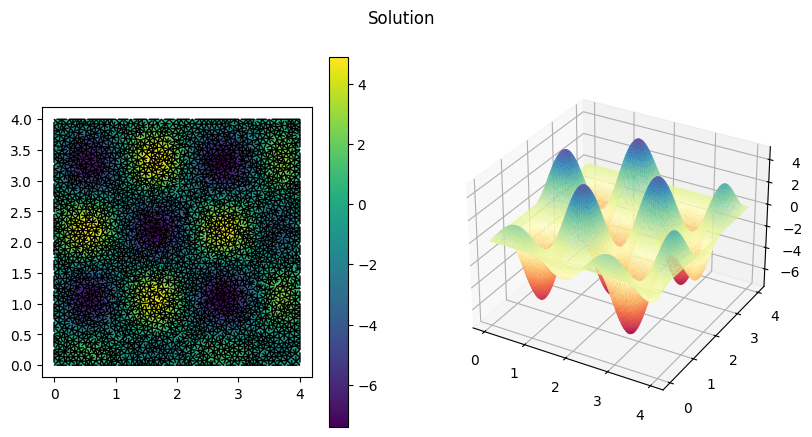

In [18]:
# Geometry definition
aMax  = 0.005
L     = 4

# Parameter definition
m0    = 0.455 # μ₀
m1    = 0.72 # μ₁

# FOM solution and plot
[mesh, dofs, strongs, u, u_strong] = libMOR.FOMSol2(L,aMax,2,m0,m1)
gedim.PlotSolution(mesh,dofs,strongs,u,u_strong)

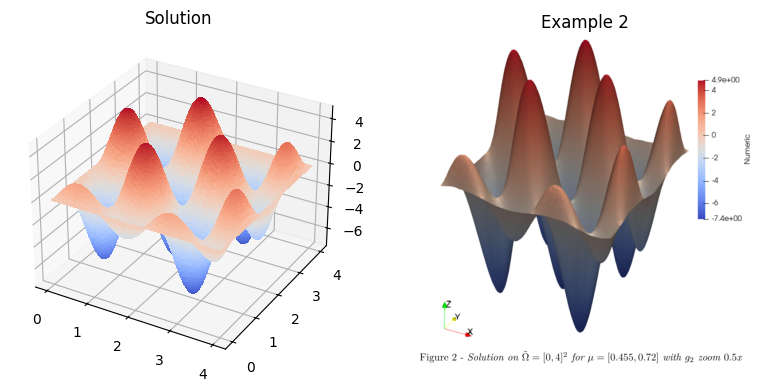

In [ ]:
# Comparison
x = np.concatenate((dofs[0,:],strongs[0,:]),axis=0)
y = np.concatenate((dofs[1,:],strongs[1,:]),axis=0)
z = np.concatenate((u,u_strong), axis=0)
triang = mlt.tri.Triangulation(x,y)

fig = plt.figure(figsize=plt.figaspect(0.5))

ax1  = fig.add_subplot(1,2,1,projection='3d')
surf = ax1.plot_trisurf(x,y,z,triangles=triang.triangles, \
                        cmap=cm.coolwarm,linewidth=0,antialiased=False)
ax1.set_title("Solution 2")

ax2 = fig.add_subplot(1,2,2)
imp = "../Figures/Example_2.png"
img = Image.open(imp)
ax2.imshow(img)
ax2.axis('off')
ax2.set_title("Example 2")

plt.show()
# plt.close(fig)

# Code taken and remixed from «PlotSolution» definition in «GeDiM4Py.py»